# Simple pulse train (multi-view ECG)

This notebook mirrors `examples/01_simple_pulse.py` and is meant for interactive exploration.
It builds a pulse-train process, defines three ECG-style views, generates a small batch, and plots two views.

Requirements:
- `torch` and `aiono`
- `matplotlib` for plotting (skip the plotting cell if you do not have it installed)


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from aiono.core.pipeline import SynthPipeline
from aiono.core.utils import utils_make_canonical_A0, utils_make_random_A0
from aiono.kernels.pqrst import make_pqrst_kernel_bank, pqrst_kernel_size
from aiono.processes.pulse_train import PulseTrainProcess
from aiono.views.ecg_leads import ECGLeadsView
from aiono.views.events import EventImpulseView, KernelConvView
from aiono.views.noise import BaselineWanderView, GaussianNoiseView
from aiono.views.units import NormalizeView
from aiono.views.sampling import SamplingAggregationView


## Device and reproducibility

Use GPU if available and fix the random seed for repeatable results.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rng = torch.Generator(device=device).manual_seed(1234)


## Define the latent process

This process generates a latent PQRST-style pulse train.


In [4]:
process = PulseTrainProcess(
    seq_len=1024,
    frequency_hz=1.2,
    sample_rate_hz=250.0,
    rhythm_classes=["regular", "irregular", "missed_beat"],
    shape_classes=["gaussian", "sharp_laplace", "biphasic_dog"],
    latent_mode="pqrst3",
    amplitude=2.0,
)


## Define observed views

Views transform the latent process into observed signals.


In [5]:
spacing = (process.seq_len - 1) / (process.num_pulses + 1)
kernel_size = pqrst_kernel_size(spacing=spacing, support_sigma=6.0)
kernels = make_pqrst_kernel_bank(
    shape_names=process.shape_classes,
    spacing=spacing,
    kernel_size=kernel_size,
    device=device,
)  # [K, T, W]
padding = kernel_size // 2

def make_views(A0: torch.Tensor) -> dict[str, torch.nn.Module]:
    def event_head() -> list[torch.nn.Module]:
        return [
            EventImpulseView(
                seq_len=process.seq_len,
                amplitude_param="amplitude",
                rounding="nearest",
            ),
            KernelConvView(kernels=kernels, padding=padding),
        ]

    return {
        "clean": torch.nn.Sequential(
            *event_head(),
            ECGLeadsView(A0=A0, jitter_std=0.0, max_delay=0),
        ),
        "noisy": torch.nn.Sequential(
            *event_head(),
            ECGLeadsView(A0=A0, jitter_std=0.05, max_delay=3),
            GaussianNoiseView(noise_std=0.1),
            BaselineWanderView(amplitude_std=0.3, freq_min=0.05, freq_max=0.2),
        ),
        "normalized_and_resampled": torch.nn.Sequential(
            *event_head(),
            ECGLeadsView(A0=A0, jitter_std=0.05, max_delay=3),
            GaussianNoiseView(noise_std=0.1),
            BaselineWanderView(amplitude_std=0.3, freq_min=0.05, freq_max=0.2),
            NormalizeView(),
            SamplingAggregationView(mode="mean", window=4),
        ),
    }

A0 = utils_make_canonical_A0(num_leads=8, num_latent=3)  # [C, K]
views = make_views(A0)


## Run the pipeline and inspect outputs


In [6]:
pipeline = SynthPipeline(process=process, views=views)
pipeline.to(device)

batch = pipeline(batch_size=4, device=device, rng=rng)

print("Generated batch keys:", batch.keys())
for name, obs in batch.items():
    signal = obs.x  # [B, C, L]
    shape_labels = obs.y["shape"]  # [B]
    rhythm_labels = obs.y["rhythm"]  # [B]

    print(f"--- View: {name} ---")
    print("  Signal shape:", signal.shape)
    print("  Shape labels:", shape_labels)
    print("  Rhythm labels:", rhythm_labels)

clean_ecg_meta = batch["clean"].view_meta("ECGLeadsView")
noisy_wander_meta = batch["noisy"].view_meta("BaselineWanderView")
print("\nView metadata:")
print("  clean ECG delays:", tuple(clean_ecg_meta["delays"].shape))
print("  noisy baseline freq:", tuple(noisy_wander_meta["freq"].shape))


Generated batch keys: dict_keys(['clean', 'noisy', 'normalized_and_resampled'])
--- View: clean ---
  Signal shape: torch.Size([4, 8, 1024])
  Shape labels: tensor([1, 0, 1, 0], device='cuda:0')
  Rhythm labels: tensor([0, 2, 0, 2], device='cuda:0')
--- View: noisy ---
  Signal shape: torch.Size([4, 8, 1024])
  Shape labels: tensor([1, 0, 1, 0], device='cuda:0')
  Rhythm labels: tensor([0, 2, 0, 2], device='cuda:0')
--- View: normalized_and_resampled ---
  Signal shape: torch.Size([4, 8, 256])
  Shape labels: tensor([1, 0, 1, 0], device='cuda:0')
  Rhythm labels: tensor([0, 2, 0, 2], device='cuda:0')


## Plot an example

This cell plots all leads from the clean and noisy views in a stacked ECG layout and saves the figure under `examples/figures`.


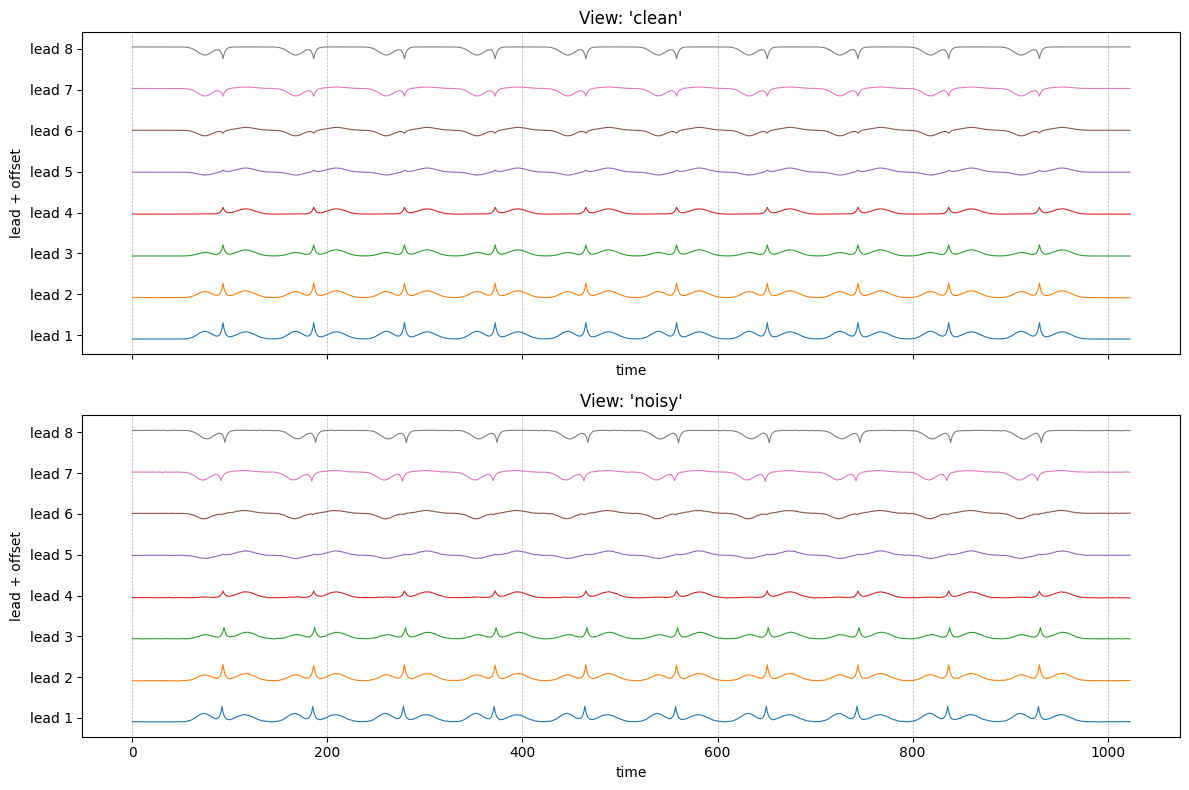

saved figure figures/01_simple_pulse.png


In [ ]:
def plot_ecg_leads(ax: plt.Axes, signal: torch.Tensor, title: str) -> None:
    signal_cpu = signal.detach().cpu()  # [C, L]
    if signal_cpu.ndim != 2:
        raise ValueError(
            "Expected a [C, L] tensor for ECG leads, "
            f"got {tuple(signal_cpu.shape)}."
        )

    num_leads, seq_len = signal_cpu.shape
    time_values = torch.arange(seq_len)  # [L]
    lead_range = signal_cpu.max(dim=1).values - signal_cpu.min(dim=1).values  # [C]
    offset_scale = lead_range.max().item()
    offsets = torch.arange(num_leads) * (offset_scale * 2.5)  # [C]

    for lead_idx in range(num_leads):
        lead_values = (signal_cpu[lead_idx] + offsets[lead_idx]).tolist()  # [L]
        ax.plot(time_values, lead_values, linewidth=0.8)

    ax.set_yticks(offsets.tolist())
    ax.set_yticklabels([f"lead {idx + 1}" for idx in range(num_leads)])
    ax.set_title(title)
    ax.set_xlabel("time")
    ax.set_ylabel("lead + offset")
    ax.grid(True, axis="x", linestyle="--", linewidth=0.5)

clean_signal = batch["clean"].x[0].detach().cpu()  # [C, L]
noisy_signal = batch["noisy"].x[0].detach().cpu()  # [C, L]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
plot_ecg_leads(ax1, clean_signal, "View: 'clean'")
plot_ecg_leads(ax2, noisy_signal, "View: 'noisy'")
plt.tight_layout()
plt.show()


## Generate with random A0

This section regenerates the views using a random mixing matrix instead of the canonical one.


In [33]:
random_a0_rng = torch.Generator(device=device).manual_seed(5678)
random_A0 = utils_make_random_A0(
    num_leads=8,
    num_latent=3,
    rng=random_a0_rng,
    device=device,
)  # [C, K]
random_views = make_views(random_A0)
random_pipeline = SynthPipeline(process=process, views=random_views)
random_pipeline.to(device)

random_rng = torch.Generator(device=device).manual_seed(5679)
random_batch = random_pipeline(batch_size=4, device=device, rng=random_rng)
print("Generated batch with random A0:", random_batch.keys())


NameError: name 'utils_make_random_A0' is not defined